# GRU Tracker — Training

Trains a GRU motion model on 12-feature rich sequences.
Saves `best_gru.pth`, `scaler_X.pkl`, `scaler_Y.pkl` to Google Drive.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random, joblib
from google.colab import drive

drive.mount('/content/drive')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Mounted at /content/drive
Using device: cuda


## 1. Load Data & Extract Velocity Features

In [2]:
BASE = '/content/drive/MyDrive/DNN_Dataset/Sequence_files/'

raw_train = np.load(BASE + 'sequences_rich_train.npy')
raw_test  = np.load(BASE + 'sequences_rich_test.npy')

print(f"raw_train: {raw_train.shape}")
print(f"raw_test:  {raw_test.shape}")

def extract_velocities(data):
    """
    Input:  (N, 11, 8)
    - features: x, y, w, h, drone_vx, drone_vy, drone_vz, altitude
    Output: (N, 10, 8)
    - features: dx, dy, w, h, drone_vx, drone_vy, drone_vz, altitude
    """
    vels = np.zeros_like(data)
    vels[:, 1:, 0] = data[:, 1:, 0] - data[:, :-1, 0]  # dx
    vels[:, 1:, 1] = data[:, 1:, 1] - data[:, :-1, 1]  # dy
    vels[:, :, 2:] = data[:, :, 2:]  # w, h + drone features
    return vels[:, 1:, :]  # drop first frame → (N, 10, 8)

# X = 10 frames of 8 features
X_train = extract_velocities(raw_train)  # (N, 10, 8)
X_test  = extract_velocities(raw_test)   # (N, 10, 8)

# Y = next frame velocity dx, dy, w, h
Y_train = np.zeros((raw_train.shape[0], 4))
Y_train[:, 0] = raw_train[:, 10, 0] - raw_train[:, 9, 0]
Y_train[:, 1] = raw_train[:, 10, 1] - raw_train[:, 9, 1]
Y_train[:, 2:] = raw_train[:, 10, 2:4]
Y_test = np.zeros((raw_test.shape[0], 4))
Y_test[:, 0] = raw_test[:, 10, 0] - raw_test[:, 9, 0]
Y_test[:, 1] = raw_test[:, 10, 1] - raw_test[:, 9, 1]
Y_test[:, 2:] = raw_test[:, 10, 2:4]

print(f"X_train: {X_train.shape} → Y_train: {Y_train.shape}")
print(f"X_test:  {X_test.shape}  → Y_test:  {Y_test.shape}")


raw_train: (141737, 11, 12)
raw_test:  (15749, 11, 12)
X_train: (141737, 10, 12) → Y_train: (141737, 4)
X_test:  (15749, 10, 12)  → Y_test:  (15749, 4)


## 2. Scale Features

In [3]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler_X = StandardScaler()
N_tr, seq_len, feats = X_train.shape

X_train_scaled = scaler_X.fit_transform(
    X_train.reshape(-1, feats)).reshape(N_tr, seq_len, feats)
X_test_scaled  = scaler_X.transform(
    X_test.reshape(-1, feats)).reshape(X_test.shape[0], seq_len, feats)

joblib.dump(scaler_X, BASE + 'scaler_X.pkl')

scaler_Y = StandardScaler()
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled  = scaler_Y.transform(Y_test)
joblib.dump(scaler_Y, BASE + 'scaler_Y.pkl')

print("Scaled ✓")
print(f"X_train_scaled: {X_train_scaled.shape}")


Scaled ✓
X_train_scaled: (141737, 10, 12)


## 3. Dataset & DataLoader

In [4]:
class SequenceDataset(Dataset):
    def __init__(self, X, Y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.Y[idx]
        if self.augment:
            x = x + torch.randn_like(x) * 0.02
            drop_prob = random.uniform(0.10, 0.15)
            for t in range(1, 10):
                if random.random() < drop_prob:
                    x[t] = x[t - 1]
        return x, y

train_dataset = SequenceDataset(X_train_scaled, Y_train_scaled, augment=True)
test_dataset  = SequenceDataset(X_test_scaled,  Y_test_scaled,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Train batches: 277 | Test batches: 31


## 4. Define GRU Model

In [5]:
class GRUTracker(nn.Module):
    def __init__(self, input_size=12, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 4)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model = GRUTracker().to(DEVICE)
dummy = torch.zeros(8, 10, 12).to(DEVICE)
assert model(dummy).shape == (8, 4)
print("Model output shape: ✓")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: ✓
Total parameters: 154,116


## 5. Training Loop

In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5)

EPOCHS    = 20
SAVE_PATH = BASE + 'best_gru.pth'

best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * len(xb)
    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(xb), yb).item() * len(xb)
    val_loss /= len(test_dataset)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Epoch {epoch:2d} | train: {train_loss:.6f} | test: {val_loss:.6f}  ✓ saved")
    else:
        print(f"Epoch {epoch:2d} | train: {train_loss:.6f} | test: {val_loss:.6f}")

Epoch  1 | train: 0.025327 | test: 0.009307  ✓ saved
Epoch  2 | train: 0.020779 | test: 0.006113  ✓ saved
Epoch  3 | train: 0.018074 | test: 0.005505  ✓ saved
Epoch  4 | train: 0.018369 | test: 0.005148  ✓ saved
Epoch  5 | train: 0.017100 | test: 0.005347
Epoch  6 | train: 0.019670 | test: 0.004369  ✓ saved
Epoch  7 | train: 0.017063 | test: 0.004316  ✓ saved
Epoch  8 | train: 0.017675 | test: 0.004164  ✓ saved
Epoch  9 | train: 0.015250 | test: 0.004374
Epoch 10 | train: 0.017226 | test: 0.002946  ✓ saved
Epoch 11 | train: 0.014879 | test: 0.003274
Epoch 12 | train: 0.016576 | test: 0.003255
Epoch 13 | train: 0.015735 | test: 0.006690
Epoch 14 | train: 0.015304 | test: 0.003118
Epoch 15 | train: 0.014509 | test: 0.002254  ✓ saved
Epoch 16 | train: 0.014770 | test: 0.002256
Epoch 17 | train: 0.013581 | test: 0.002604
Epoch 18 | train: 0.014009 | test: 0.002392
Epoch 19 | train: 0.013537 | test: 0.002253  ✓ saved
Epoch 20 | train: 0.012276 | test: 0.001954  ✓ saved


## 6. Training Loss Curve

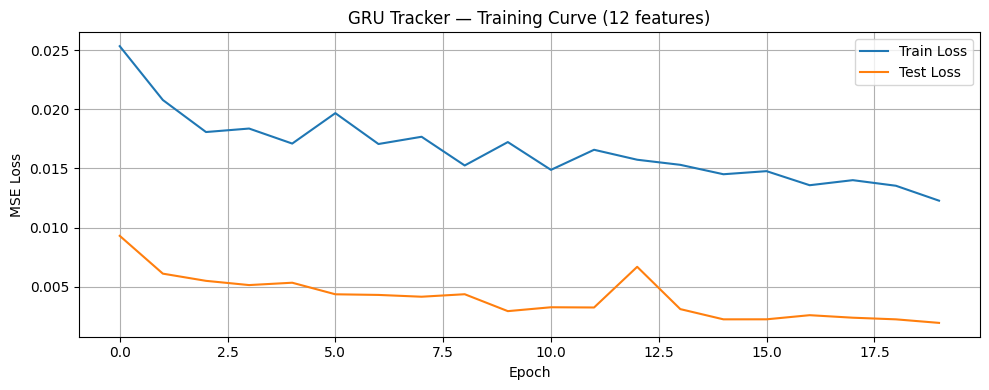

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Test Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('GRU Tracker — Training Curve (12 features)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(BASE + 'gru_loss_curve.png')
plt.show()